 Files in Colab:
['.config', 'movies_data.csv', 'sample_data']

 Dataset Preview
                                 Name  Year  Duration  \
0  #Gadhvi (He thought he was Gandhi)  2019       109   
1                             #Yaaram  2019       110   
2                ...Aur Pyaar Ho Gaya  1997       147   
3                           ...Yahaan  2005       142   
4                  ?: A Question Mark  2012        82   

                       Genre  Rating  Votes        Director          Actor 1  \
0                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
1            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
2     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
3        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
4  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

                  Actor 2          Actor 3  
0          Vivek Ghamande    Arvind Jangid  
1    

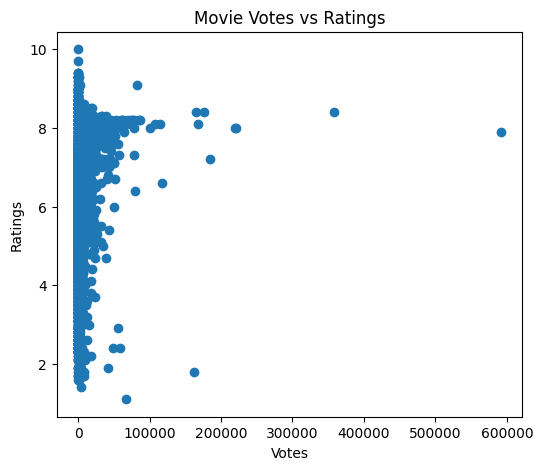

In [3]:
# Movie Rating Prediction
# CodSoft Internship Project

import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Show uploaded files
print(" Files in Colab:")
print(os.listdir('/content'))

# Load dataset
movie_data = pd.read_csv('/content/movies_data.csv', encoding='latin1')

print("\n Dataset Preview")
print(movie_data.head())

# Remove missing values
movie_data = movie_data.dropna()

# Convert votes column
movie_data['Votes'] = movie_data['Votes'].astype(str)
movie_data['Votes'] = movie_data['Votes'].str.replace(',', '')
movie_data['Votes'] = pd.to_numeric(movie_data['Votes'])

# Features and target
X = movie_data[['Votes']]
y = movie_data['Rating']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Model score
score = r2_score(y_test, predictions)

print("\n Movie Rating Prediction Completed")
print(f" Model Score: {score:.2f}")

# Visualization
plt.figure(figsize=(6,5))

plt.scatter(
    movie_data['Votes'],
    movie_data['Rating']
)

plt.title("Movie Votes vs Ratings")
plt.xlabel("Votes")
plt.ylabel("Ratings")

plt.show()